# Colorado Spills 
## OLS, NBR, Interrupted Time Series Analysis
## Just top 3 Counties
### Author: [David P. Adams, PhD](https://dadams.io)
#### Date: 2025-07-02

---


# Setup

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import geopandas as gpd
from dotenv import load_dotenv
load_dotenv()

import os

# Database connection details from zshrc environment variables
#  use .env file for local development


db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')


# Create an engine to connect to the PostgreSQL database
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# Read in the spills_with_demographics_geog as spills
spills = pd.read_sql_table('spills_with_demographics_geog', engine)



/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/pandas/io/sql.py:1725: SAWarning: Did not recognize type 'geometry' of column 'geometry'
  self.meta.reflect(bind=self.con, only=[table_name], views=True)


In [2]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])

In [3]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [4]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])



In [5]:
# keep only records where year is between 2017 and 2023 (inclusive)
spills_gdf = spills_gdf[
    (spills_gdf['Date of Discovery'].dt.year >= 2017) &
    (spills_gdf['Date of Discovery'].dt.year < 2024) &
    (spills_gdf['Initial Report Date'].dt.year >= 2017) &
    (spills_gdf['Initial Report Date'].dt.year < 2024)
]



In [6]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [7]:
# only use the top 3 counties by number of spills
top_counties = spills_gdf['county'].value_counts().nlargest(3).index.tolist()
# filter spills_gdf to only include top counties
spills_gdf = spills_gdf[spills_gdf['county'].isin(top_counties)]
# filter historical spills to only include top counties
historical_spills = historical_spills[historical_spills['county'].isin(top_counties)]
# filter recent spills to only include top counties
recent_spills = recent_spills[recent_spills['county'].isin(top_counties)]

In [8]:
import statsmodels.formula.api as smf

# Create 'Period' column
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')


In [9]:
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type'
})


---

# OLS Regression

In [10]:
import statsmodels.formula.api as smf

model = smf.ols("report_delay ~ C(spill_type) * C(Period)", data=spills_gdf).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.895
Date:                Wed, 02 Jul 2025   Prob (F-statistic):             0.0339
Time:                        12:54:40   Log-Likelihood:                -40805.
No. Observations:                9087   AIC:                         8.162e+04
Df Residuals:                    9083   BIC:                         8.165e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

---

# Negative Binomial Regression

In [11]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure spill_type and Period are clean, and report_delay is numeric
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type'
})

# Fit the Negative Binomial model with interaction
nb_model = smf.glm(
    formula="report_delay ~ C(spill_type) * C(Period)",
    data=spills_gdf,
    family=sm.families.NegativeBinomial()
).fit()

# View the results
print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:           report_delay   No. Observations:                 9087
Model:                            GLM   Df Residuals:                     9083
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -19592.
Date:                Wed, 02 Jul 2025   Deviance:                       19541.
Time:                        12:54:40   Pearson chi2:                 3.97e+05
No. Iterations:                     8   Pseudo R-squ. (CS):            0.04240
Covariance Type:            nonrobust                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------

/home/dadams/miniconda3/envs/spatial_env2/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [12]:
import numpy as np
np.exp(nb_model.params)


Intercept                                           3.681838
C(spill_type)[T.Recent]                             0.690093
C(Period)[T.Before 2020]                            0.886766
C(spill_type)[T.Recent]:C(Period)[T.Before 2020]    0.850281
dtype: float64

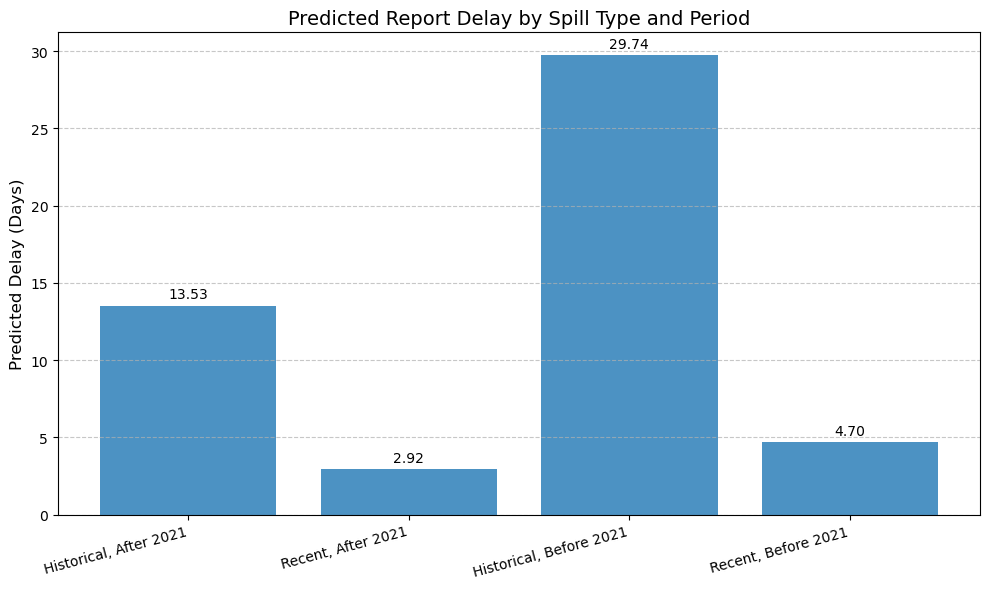

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Predicted delays by group
group_labels = [
    "Historical, After 2021",
    "Recent, After 2021",
    "Historical, Before 2021",
    "Recent, Before 2021"
]

# From your exponentiated results
predicted_delays = [
    13.53,                         # Intercept only
    13.53 * 0.216,                 # Intercept * Recent
    13.53 * 2.198,                 # Intercept * Before 2021
    13.53 * 0.216 * 2.198 * 0.732  # Intercept * Recent * Before 2021 * Interaction
]

# Create DataFrame for plotting
df_plot = pd.DataFrame({
    "Group": group_labels,
    "Predicted Delay (Days)": predicted_delays
})

# Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(df_plot["Group"], df_plot["Predicted Delay (Days)"], alpha=0.8)
plt.title("Predicted Report Delay by Spill Type and Period", fontsize=14)
plt.ylabel("Predicted Delay (Days)", fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),  # 3 points vertical offset
                 textcoords="offset points",
                 ha='center', va='bottom')

plt.show()


---

# Interrupted Time Series

                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                 -0.021
Method:                 Least Squares   F-statistic:                    0.4256
Date:                Wed, 02 Jul 2025   Prob (F-statistic):              0.735
Time:                        12:54:41   Log-Likelihood:                -211.00
No. Observations:                  84   AIC:                             430.0
Df Residuals:                      80   BIC:                             439.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.2068      0.867      2.546      0.0

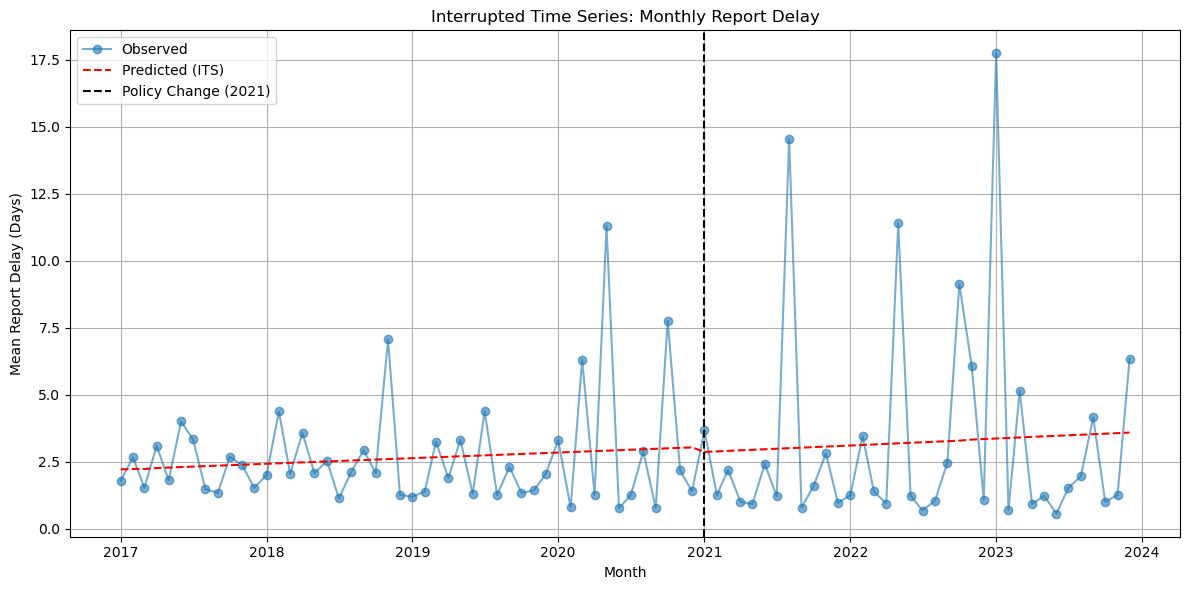

In [14]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Convert to monthly time series
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly = spills_gdf.groupby('report_month')['report_delay'].mean().reset_index()
monthly['report_month'] = monthly['report_month'].dt.to_timestamp()

# 2. Create ITS variables
monthly['time'] = (monthly['report_month'] - monthly['report_month'].min()).dt.days // 30
monthly['post_2021'] = (monthly['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly['time_post'] = monthly['time'] * monthly['post_2021']

# 3. Run the ITS model
its_model = smf.ols("report_delay ~ time + post_2021 + time_post", data=monthly).fit()
print(its_model.summary())

# 4. Predict and plot
monthly['predicted'] = its_model.predict(monthly)

plt.figure(figsize=(12, 6))
plt.plot(monthly['report_month'], monthly['report_delay'], marker='o', label='Observed', alpha=0.6)
plt.plot(monthly['report_month'], monthly['predicted'], linestyle='--', color='red', label='Predicted (ITS)')
plt.axvline(x=pd.Timestamp('2021-01-01'), color='black', linestyle='--', label='Policy Change (2021)')
plt.title('Interrupted Time Series: Monthly Report Delay')
plt.xlabel('Month')
plt.ylabel('Mean Report Delay (Days)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## ITS by Spill Type

In [15]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# Group by month and spill type
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly_by_type = spills_gdf.groupby(['report_month', 'spill_type'])['report_delay'].mean().reset_index()
monthly_by_type['report_month'] = monthly_by_type['report_month'].dt.to_timestamp()

# ITS variables
monthly_by_type['time'] = (monthly_by_type['report_month'] - monthly_by_type['report_month'].min()).dt.days // 30
monthly_by_type['post_2021'] = (monthly_by_type['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly_by_type['time_post'] = monthly_by_type['time'] * monthly_by_type['post_2021']

# Run ITS models and print summaries
its_results_by_type = {}
for stype in monthly_by_type['spill_type'].unique():
    df = monthly_by_type[monthly_by_type['spill_type'] == stype].copy()
    model = smf.ols("report_delay ~ time + post_2021 + time_post", data=df).fit()
    df['predicted'] = model.predict(df)
    its_results_by_type[stype] = (model, df)
    
    print(f"\n=== ITS Model Summary for {stype} Spills ===\n")
    print(model.summary())



=== ITS Model Summary for Historical Spills ===

                            OLS Regression Results                            
Dep. Variable:           report_delay   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.4853
Date:                Wed, 02 Jul 2025   Prob (F-statistic):              0.693
Time:                        12:54:41   Log-Likelihood:                -237.68
No. Observations:                  84   AIC:                             483.4
Df Residuals:                      80   BIC:                             493.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
In

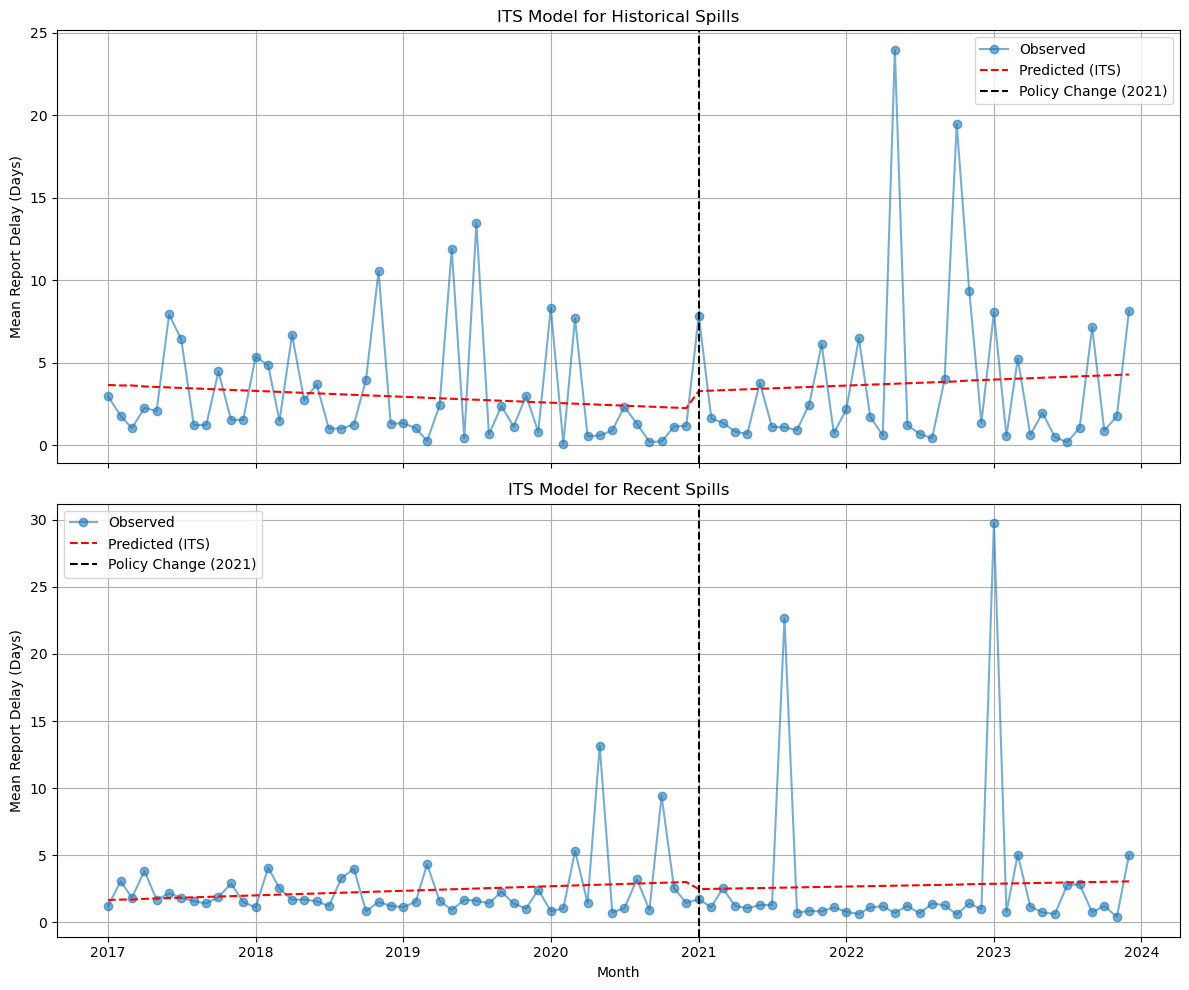

In [16]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# 1. Group by month and spill type
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M')
monthly_by_type = spills_gdf.groupby(['report_month', 'spill_type'])['report_delay'].mean().reset_index()
monthly_by_type['report_month'] = monthly_by_type['report_month'].dt.to_timestamp()

# 2. Create ITS variables
monthly_by_type['time'] = (monthly_by_type['report_month'] - monthly_by_type['report_month'].min()).dt.days // 30
monthly_by_type['post_2021'] = (monthly_by_type['report_month'] >= pd.Timestamp('2021-01-01')).astype(int)
monthly_by_type['time_post'] = monthly_by_type['time'] * monthly_by_type['post_2021']

# 3. Run ITS models separately by spill type
its_results_by_type = {}
for stype in monthly_by_type['spill_type'].unique():
    df = monthly_by_type[monthly_by_type['spill_type'] == stype].copy()
    model = smf.ols("report_delay ~ time + post_2021 + time_post", data=df).fit()
    df['predicted'] = model.predict(df)
    its_results_by_type[stype] = (model, df)

# 4. Plot side-by-side
fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, (stype, (model, df)) in zip(axs, its_results_by_type.items()):
    ax.plot(df['report_month'], df['report_delay'], marker='o', label='Observed', alpha=0.6)
    ax.plot(df['report_month'], df['predicted'], linestyle='--', color='red', label='Predicted (ITS)')
    ax.axvline(x=pd.Timestamp('2021-01-01'), color='black', linestyle='--', label='Policy Change (2021)')
    ax.set_title(f"ITS Model for {stype} Spills")
    ax.set_ylabel("Mean Report Delay (Days)")
    ax.legend()
    ax.grid(True)

axs[1].set_xlabel("Month")
plt.tight_layout()
plt.show()


---

# Conclusion: Comparative Summary


In [17]:
def extract_regression_results(model, model_name):
    coefs = model.params
    ses = model.bse
    pvals = model.pvalues

    df = pd.DataFrame({
        'Coefficient': coefs,
        'Std. Error': ses,
        'P-Value': pvals
    })
    df['Model'] = model_name
    return df.reset_index().rename(columns={'index': 'Term'})


In [18]:
# Collect regression summaries
results_frames = []

# Add your models — use your actual variable names
results_frames.append(extract_regression_results(model, 'OLS (Interaction)'))
results_frames.append(extract_regression_results(nb_model, 'Negative Binomial'))
results_frames.append(extract_regression_results(its_model, 'ITS (Monthly, All Spills)'))


# ITS by spill type (e.g., 'Historical', 'Recent')
for spill_type, (model, df) in its_results_by_type.items():
    label = f"ITS (Monthly, {spill_type})"
    results_frames.append(extract_regression_results(model, label))

# Combine all
regression_summary_table = pd.concat(results_frames, ignore_index=True)

# Pivot just the coefficients for display
regression_coef_table = regression_summary_table.pivot_table(
    index='Term',
    columns='Model',
    values='Coefficient',
    aggfunc='first'
).round(3)

regression_coef_table


Model,"ITS (Monthly, All Spills)","ITS (Monthly, Historical)","ITS (Monthly, Recent)",Negative Binomial,OLS (Interaction)
Term,,,,,
C(Period)[T.Before 2020],NaN,NaN,NaN,-0.120,NaN
C(spill_type)[T.Recent],NaN,NaN,NaN,-0.371,NaN
C(spill_type)[T.Recent]:C(Period)[T.Before 2020],NaN,NaN,NaN,-0.162,NaN
Intercept,2.207,3.646,1.660,1.303,1.660
post_2021,-0.312,-1.713,0.044,NaN,0.044
time,0.017,-0.030,0.028,NaN,0.028
time_post,0.003,0.058,-0.013,NaN,-0.013
